# Noisy Lorenz attractor

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lindermanlab/helmholtz-sde/blob/main/experiments/lorenz/lorenz_attractor.ipynb)

In this notebook, we provide an introduction to the `helmholtz_sde` package using observations generated according to the chaotic Lorenz system. 
We demonstrate that Helmholtz-SDE learns the Lorenz attractor dynamics to high fidelity from noisy observations.

The dataset we consider is adapted from
```
Li, X., et al., Scalable gradients and variational inference for stochastic differential equations. Symposium on Advances in Approximate Bayesian Inference, 2020.
```

## Running in Colab

The cell below clones the repository and installs the package when this notebook runs in Google Colab; it does nothing when the notebook runs locally. A GPU runtime is recommended. You may need to restart the runtime in order for Colab to pick up the correct package dependencies. The package requires Python `>=3.12`, and the dataset is generated inside the notebook, so nothing needs to be downloaded.

In [ ]:
# Colab setup: install the package and move into this notebook's directory so that lorenz_utils is importable
import importlib.util
import os
import sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    if not os.path.exists("/content/helmholtz-sde"):
        !git clone -q https://github.com/lindermanlab/helmholtz-sde.git /content/helmholtz-sde
    %pip install -q "jax[cuda12]==0.5.3" "jaxlib==0.5.3" "flax==0.10.6" "optax==0.2.6" "tensorflow-probability==0.25.0"
    %pip install -q "/content/helmholtz-sde[experiments]"
    importlib.invalidate_caches()
    if "jax" in sys.modules and sys.modules["jax"].__version__ != "0.5.3":
        raise RuntimeError("restart the runtime and run this cell again")
    os.chdir("/content/helmholtz-sde/experiments/lorenz")
    sys.path.insert(0, os.getcwd())
    print(f"Colab setup complete (python {sys.version.split()[0]}, cwd {os.getcwd()})")

## Imports

In [2]:
# Generic imports
import jax
import jax.numpy as jnp
import jax.random as jr
from jax import vmap

import numpy as np

import pickle

from functools import partial
jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt

In [3]:
# Imports from helmholtz_sde
from helmholtz_sde.utils.general_helpers import simulate_sde, simulate_learned_prior_samples
from helmholtz_sde.utils.plotting import time_to_index, plot_marginal_trajectories, plot_latent_3d_projection, plot_posterior_marginals, plot_posterior_samples, plot_losses
from helmholtz_sde.sde import NeuralSDE, DriftNetwork, DiffusionNetwork
from helmholtz_sde.posterior.encoder import weighted_ctx, ForwardGRUEncoder
from helmholtz_sde.posterior.nn_posterior import InferenceNetwork
from helmholtz_sde.posterior.drift import PosteriorSDE, simulate_posterior_samples
from helmholtz_sde.helmholtz.subspace import LeastSquaresCorrection
from helmholtz_sde.train import train
from helmholtz_sde.data import process_data_full_kl

In [4]:
# Imports for evaluating the dynamics
sys.path.append("..") # shared experiment code
from experiment_utils import eval_correction
from lorenz_utils import (
    GaussianFixedVariance,
    LorenzAttractor,
    compute_lorenz_fixed_points,
    compute_lorenz_rotation_summaries,
    plot_lagged_autocorr_compare,
    plot_lobe_lagged_correlation_matrices,
    plot_rts_posterior_marginals,
    posterior_true_logprob,
    run_ie_rts_smoother_batch_fast,
)

In [5]:
# Auto-reload notebook
if not IN_COLAB:
    %load_ext autoreload
    %autoreload 2

## Dataset generation and visualization

To start, we generate and visualize the noisy Lorenz attractor dataset.

We first generate the ground-truth latents according to the stochastic Lorenz attractor

\begin{align*}
d \boldsymbol{z}(t) = \begin{pmatrix} \alpha (\boldsymbol{z}_2(t) - \boldsymbol{z}_1(t))\\ \boldsymbol{z}_1(t) (\rho - \boldsymbol{z}_3(t)) - \boldsymbol{z}_2(t) \\ \boldsymbol{z}_1(t) \boldsymbol{z}_2(t) - \beta \boldsymbol{z}_3(t)\end{pmatrix}dt + \sigma d \boldsymbol{w}(t), \quad \boldsymbol{z}(t) \in \mathbb{R}^3, \quad \boldsymbol{z}(0) \sim N(\boldsymbol{0}, \mathbb{I}_3)
\end{align*}

The first term is the Lorenz attractor dynamics and the second is a standard Brownian motion which injects noise into the system at all times $0 \leq t \leq T$.
We choose Lorenz drift  parameters $(\alpha, \rho, \beta) = (10, 28, 8/3)$ and diffusion coefficient $\sigma = 5 \cdot \mathbb{I}_3$. We discretize the SDE on $[0, T], T = 5$ using the Euler-Maruyama discretization with stepsize $10^{-3}$.

In [6]:
D = 3 # output dimension
sde_true = LorenzAttractor(D) # ground truth Lorenz dynamics
sigma = 5.0 # diffusion coefficient 

dataset_dir = None # NOTE: set to your dataset path if loading existing dataset

if dataset_dir is not None: # load the dataset
    train_path = os.path.join(dataset_dir, "train.pkl")
    test_path = os.path.join(dataset_dir, "test.pkl")

    with open(train_path, "rb") as f:
        blob_train = pickle.load(f)
    xs_train = jnp.array(blob_train["xs"])
    t_grid = jnp.array(blob_train["t_grid"])
    t_max, n_timesteps = t_grid[-1].item(), t_grid.shape[0] - 1
    a = jnp.array(blob_train["sde_params"])
    means = jnp.array(blob_train["means"])
    stds = jnp.array(blob_train["stds"])
    sigma = blob_train["sigma"]
    sde_params_true = {"a": a, "G": sigma * jnp.eye(D)}

    with open(test_path, "rb") as f:
        xs_test = pickle.load(f)
    xs_test = jnp.array(xs_test)
    n_samples = xs_train.shape[0] + xs_test.shape[0]
    n_train, n_test = xs_train.shape[0], xs_test.shape[0]
else: # simulate the SDE
    a = jnp.array([10., 28., 8./3.])
    sde_params_true = {"a": a, "G": sigma * jnp.eye(D)}

    t_max = 5.0
    n_timesteps = int(t_max * 1000)
    t_grid = jnp.linspace(0., t_max, n_timesteps+1)
    n_samples = 1024 * (1 + 2) # 1024 samples, 2048 test samples
    init_key, sample_key = jr.split(jr.PRNGKey(0), 2)
    
    x0 = jr.normal(init_key, shape=(n_samples, D)) # N(0, I) initialization in x space
    xs = vmap(partial(simulate_sde, sde=sde_true, sde_params=sde_params_true, t_max=t_max, n_timesteps=n_timesteps))(jr.split(sample_key, n_samples), x0)

    stds = jnp.std(jnp.reshape(xs, (-1, D)), axis=0)
    means = jnp.mean(jnp.reshape(xs, (-1, D)), axis=0)
    
    n_train = 1024
    xs_train = xs[:n_train]
    xs_test = xs[n_train:]
    n_test = xs_test.shape[0]

    save_dir = "../datasets/lorenz"
    train_path = os.path.join(save_dir, "train.pkl")
    test_path = os.path.join(save_dir, "test.pkl")
    os.makedirs(save_dir, exist_ok=True)

    # Save train
    with open(train_path, "wb") as f:
        pickle.dump({"xs": np.asarray(xs_train), "t_grid": np.asarray(t_grid), "sde_params": np.asarray(a), "sigma": sigma, "means": np.asarray(means), "stds": np.asarray(stds)}, f)

    # Save test
    with open(test_path, "wb") as f:
        pickle.dump(np.asarray(xs_test), f)

Next, we standardize the latents as described by `Li et al., 2020` and sample our observations of the latent state. 
We observe a noisy version of the latent state every $\Delta t = 0.25$ time units. 

Our model for the observations $\boldsymbol{y} = \{ \boldsymbol{y}(t_n)\}_{n=1}^N$ is

\begin{align*}
\boldsymbol{y}(t_n) = \boldsymbol{C}_{\mathrm{true}} \boldsymbol{z}(t_n) +  \boldsymbol{d}_{\mathrm{true}} + \boldsymbol{\varepsilon}(t_n), \quad \boldsymbol{\varepsilon}(t_n) \sim N(\boldsymbol{0}, \eta^2 \mathbb{I}_3),
\end{align*}

where $\boldsymbol{C}_{\mathrm{true}} \in \mathbb{R}^{3 \times 3}$ and $\boldsymbol{d}_{\mathrm{true}} \in \mathbb{R}^{3}$ define the affine output mapping and $\eta = 0.3$ is the observation noise.


In [7]:
ssigma = 0.3 # observation noise
n_obs = 4 * int(t_max) + 1 # number of observations per trial
n_test = min(2048, xs_test.shape[0]) # number of test trials

C_true = jnp.diag(1/stds)
d_true = - means/stds
output_params_true = {"C": C_true, "d": d_true}
def _apply_affine(x):
    return C_true @ x + d_true
_apply_affine_batched = vmap(lambda xs: vmap(lambda x: _apply_affine(x))(xs))


obs_key = jr.PRNGKey(1)
obs_key_train, obs_key_test = jr.split(obs_key, 2)

if n_obs == 1:
    idx_obs = jnp.array([1])
else:
    idx_obs = jnp.array([time_to_index(t, t_max, n_timesteps + 1) for t in (t_max / (n_obs - 1)) * jnp.arange(n_obs)])
obs_times_train = jnp.broadcast_to(t_grid[idx_obs], (n_train, n_obs))
obs_times_test = jnp.broadcast_to(t_grid[idx_obs], (n_test, n_obs))

# True latents (in standardized coordinates)
ys_train = _apply_affine_batched(xs_train)
ys_test = _apply_affine_batched(xs_test)

# Observations
ys_obs_train = ys_train[jnp.arange(n_train)[:, None], idx_obs] + ssigma * jr.normal(obs_key_train, shape=(n_train, n_obs, D))
ys_obs_test = ys_test[jnp.arange(n_test)[:, None], idx_obs] + ssigma * jr.normal(obs_key_test, shape=(n_test, n_obs, D))

We visualize the ground truth trajectories. 
Observations are shown as `x`'s.

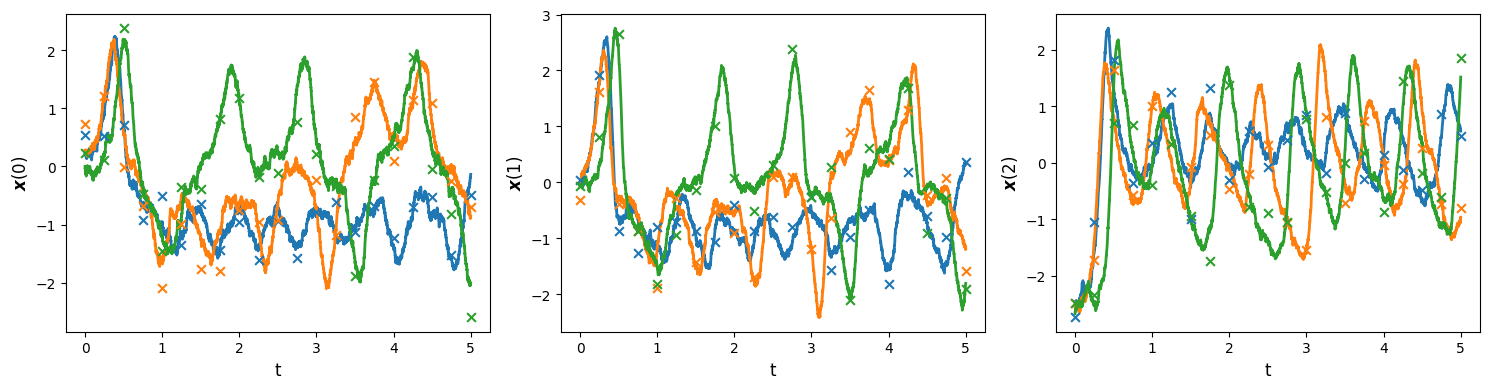

In [8]:
# Plot some ground truth trajectories
n_trajs = 3
fig, axs = plot_marginal_trajectories(ys_train, t_max=t_max, n_trajs=n_trajs, linewidth=2)
for j, ax in enumerate(axs):
    for i in range(n_trajs):
        c = ax.lines[i].get_color()
        ax.scatter(obs_times_train[i], ys_obs_train[i, :, j], marker="x", color=c, s=40, linewidths=1.5, zorder=3)
plt.show()

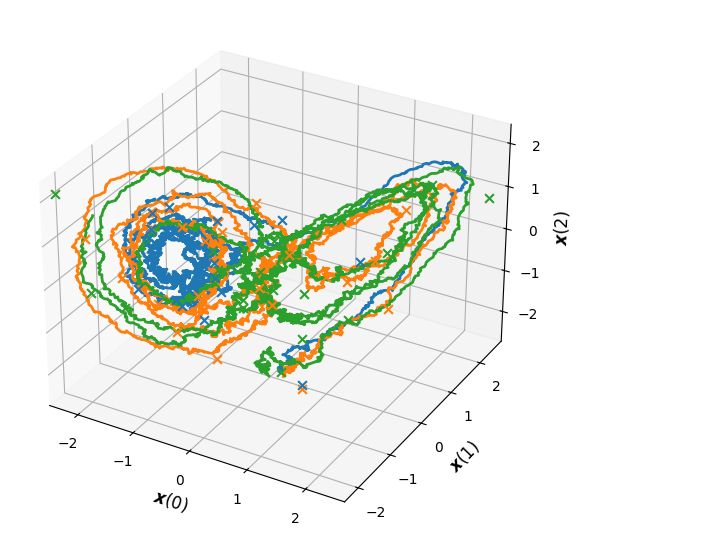

In [9]:
fig, axs = plot_latent_3d_projection(ys_train, n_trajs=n_trajs, linewidth=2)
for i in range(n_trajs):
    c = axs.lines[i].get_color()
    axs.scatter(ys_obs_train[i, :, 0], ys_obs_train[i, :, 1], ys_obs_train[i, :, 2], marker="x", color=c, s=40, linewidths=1.5, zorder=3, depthshade=False)
plt.show()

## Fitting Helmholtz-SDE

Now, we show that we can recover the Lorenz attractor dynamics to high fidelity using Helmholtz-SDE. 
We do so using _simulation-free variational inference (VI)_. 

Our generative model specifies that the latent variable $\boldsymbol{x}(t) \in \mathbb{R}^K$ evolves over the interval $0 \leq t \leq T$ according a stochastic differential equation (SDE) with dynamics function $\boldsymbol{f}_p(\cdot | \boldsymbol{\theta})$ and diffusion coefficient $\boldsymbol{\Sigma}(\boldsymbol{\theta})^{1/2}$.
The latents then generate the observations $\{\boldsymbol{y}(t_n)\}_{n=1}^N$ at a finite set of time points $\{ t_n \}_{n=1}^N$.
We denote the parameters of the generative model by $\boldsymbol{\theta}$ and the marginal distribution of the latent variable at each time $0 \leq t \leq T$ by $p(\boldsymbol{x}, t | \boldsymbol{\theta})$.
For our experiments, we choose latent dimension $K = 4$.

Since the prior dynamics $\boldsymbol{f}_p$ is nonlinear, the posterior over $(\boldsymbol{x}(t))_{0 \leq t \leq T}$ given $\boldsymbol{y}$ is intractable. 
We approximate it by a distribution $\mathbb{Q}_{\boldsymbol{\phi}}$ belonging to a tractable family, known as a _variational family_. 
$\boldsymbol{\phi}$ are the parameters of the variational distribution $\mathbb{Q}_{\boldsymbol{\phi}}$.
We choose $\mathbb{Q}_{\boldsymbol{\phi}}$ to be a diffusion process having Gaussian marginals at each time $0 \leq t \leq T$, written $q(\boldsymbol{x}, t | \boldsymbol{\phi}) = N(\boldsymbol{m}(t | \boldsymbol{\phi}), \boldsymbol{S}(t | \boldsymbol{\phi}))$.
The drift of the approximate posterior $\mathbb{Q}_{\boldsymbol{\phi}}$ is denoted by $\boldsymbol{f}_q(\boldsymbol{x}, t | \boldsymbol{\phi})$.

Once we have specified both the generative model and the approximate posterior, we consider the negative evidence lower bound (ELBO)
\begin{align*}
L(\boldsymbol{\theta}, \boldsymbol{\phi}) = -\sum_{n=1}^N \mathbb{E}_{\mathbb{Q}_{\boldsymbol{\phi}}} \log p(\boldsymbol{y}(t_n) | \boldsymbol{x}(t_n), \boldsymbol{\theta}) +  \mathrm{KL}(q(\boldsymbol{x}, 0 | \boldsymbol{\phi}) || p(\boldsymbol{x}, 0 | \boldsymbol{\theta})) + \int_0^T \mathbb{E}_{\mathbb{Q}_{\boldsymbol{\phi}}} \| \boldsymbol{\Sigma}^{-1/2} \{ \boldsymbol{f}_p(\boldsymbol{x}(t) | \boldsymbol{\theta}) -  \boldsymbol{f}_q(\boldsymbol{x}(t), t | \boldsymbol{\phi}) \}\|^2 dt.
\end{align*}
For all $\boldsymbol{\phi}$, $L$ is an upper bound to the negative log marginal probability of the observations $\log p(\boldsymbol{y} | \boldsymbol{\theta})$.

In Helmholtz-SDE, we minimize an unbiased estimate to the negative ELBO, jointly with respect to the generative model parameters $\boldsymbol{\theta}$ and the variational parameters $\boldsymbol{\phi}$.

We first define the generative model.

In [10]:
n_trials = 1024

K = 4 # latent dimension
hidden_dim = 100
embedding_size = hidden_dim
depth = 2
learn_prior = True
learn_output = True
div_free = LeastSquaresCorrection(ell=1, kappa=1, n_mc=1) # divergence-free correction
gauge = "sqrt" # choose the posterior reference drift from SDE Matching (Bartosh et al., 2025)
div_free_eval = eval_correction(div_free, n_nodes=6) # correction used when sampling the posterior SDE

In [11]:
drift_net = DriftNetwork(hidden_dim=hidden_dim, K=K, depth=1, include_time=False)
init_key_drift, init_key_diff = jr.split(jr.PRNGKey(2), 2)

# Initialize the drift network
network_params = drift_net.init(init_key_drift, jnp.zeros((K,)), jnp.zeros((1,))) 

# Specify diffusion coefficient
if div_free is None and gauge == "sqrt": # learn a state-dependent diffusion coefficient
    diff_net = DiffusionNetwork(hidden_dim=hidden_dim, K=K, depth=1, include_time=False)
    network_params_diff = diff_net.init(init_key_diff, jnp.zeros((K,)), jnp.zeros((1,))) 
    sde_params = {"network_params_drift": network_params, "network_params_diffusion": network_params_diff}
    apply_fn_diff = diff_net.apply
    div_GGt_apply_fn = lambda params, x, t: diff_net.apply(params, x, t, method=DiffusionNetwork.div_GGt)
else: # fix the diffusion coefficient to the identity
    sde_params = {"network_params_drift": network_params, "network_params_diffusion": None}
    apply_fn_diff, div_GGt_apply_fn = None, None

prior = NeuralSDE(K, apply_fn_drift=drift_net.apply, apply_fn_diffusion=apply_fn_diff, div_GGt_apply_fn=div_GGt_apply_fn)

# Initial prior initial parameters
mu0 = jnp.zeros((K))
V0 = jnp.eye(K)
init_params = {"mu0": mu0, "V0": V0}

In [12]:
# Parameters of likelihood model
init_key_output = jr.PRNGKey(3)
C_init_key, d_init_key = jr.split(init_key_output, 2)
output_params_init = {"C": jr.normal(key=C_init_key, shape=(D, K)), "d": jr.normal(key=d_init_key, shape=(D,))}

likelihood = GaussianFixedVariance(ssigma=ssigma)

Since we learn the dynamics using $1024$ trials, we amortize the posterior approximation across trials. 
In particular, we encode the observations for each trial using a GRU and then produce the posterior parameters using the per-trial embedding.

In [13]:
ys_obs_partial = ys_obs_train[:n_trials]
obs_times_partial = obs_times_train[:n_trials]

# Amortized posterior approximation
post_net = InferenceNetwork(hidden_dim=hidden_dim, K=K, depth=depth, jitter=1e-8)
# Encode observations (T, D) -> (T+1, H)
encoder = ForwardGRUEncoder(embedding_size)
# Combines encodings across time to produce per-trial embedding (T+1, H) -> (H)
process_ctx = partial(weighted_ctx, beta=n_obs)

Now that we have defined the generative model and the approximate posterior, we are prepared to fit the model.

In [14]:
n_iters = 30000

params, metrics = train(
    jr.PRNGKey(11), 
    ys_obs_partial, 
    obs_times_partial,
    likelihood, 
    output_params_init, 
    t_max, 
    encoder, 
    process_ctx, 
    post_net, 
    prior, 
    sde_params, 
    init_params, 
    learning_rate_init=1e-3, # initial learning rate
    learning_rate_final=1e-3, # final learning rate
    mc_samples=1, # number of MC samples to approximate KL, likelihood (per trial)
    jitter=1e-8, 
    n_iters=n_iters,
    div_free=div_free, 
    learn_prior=learn_prior,
    learn_output=learn_output,
    gauge=gauge,
    grad_clip_norm=5.0,
    process_data=partial(process_data_full_kl, t_max=t_max),
)

100%|██████████| 30000/30000 [04:23<00:00, 113.83it/s, kl=30.9, kl_w=1, loss=47.8, prior=0.601, rec=16.4]    


## Comparison to SDE Matching

We compare our variational inference algorithm to SDE Matching `(Bartosh et al., 2025)`, a simulation-free variational inference algorithm that uses a smaller variational family than Helmholtz-SDE.

In [15]:
_, metrics_sde_matching = train(
    jr.PRNGKey(11), 
    ys_obs_partial, 
    obs_times_partial,
    likelihood, 
    output_params_init, 
    t_max, 
    encoder, 
    process_ctx, 
    post_net, 
    prior, 
    sde_params, 
    init_params, 
    learning_rate_init=1e-3,
    learning_rate_final=1e-3,
    mc_samples=1,
    jitter=1e-8, 
    n_iters=n_iters,
    div_free=None, 
    learn_prior=learn_prior,
    learn_output=learn_output,
    gauge=gauge,
    grad_clip_norm=5.0,
    process_data=partial(process_data_full_kl, t_max=t_max),
)

100%|██████████| 30000/30000 [03:54<00:00, 128.11it/s, kl=55.8, kl_w=1, loss=71.2, prior=0.655, rec=14.7]    


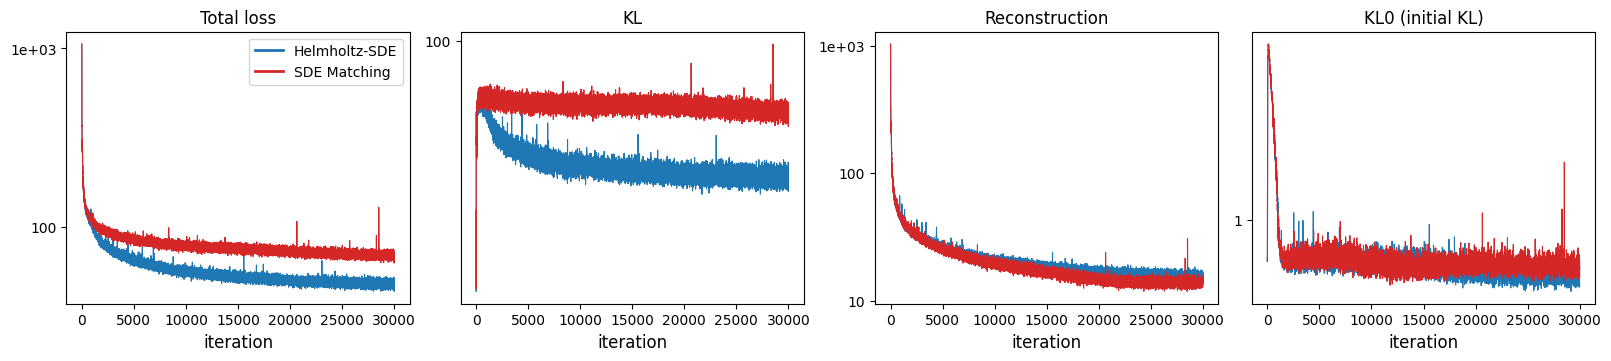

In [16]:
# Training loss curves of Helmholtz-SDE and SDE Matching
fig, axs = plot_losses([metrics, metrics_sde_matching], labels=["Helmholtz-SDE", "SDE Matching"], colors=["tab:blue", "tab:red"])
plt.show()

We see that there is an approximately 20 nat gap in the negative evidence lower bound between Helmholtz-SDE and SDE Matching.

## Visualization and evaluation of results

### Posterior approximation

We assess the quality of the amortized posterior approximation by visualizing the posterior mean and $\pm2$ posterior standard deviations against the ground truth latents (grey) for the first few trials.

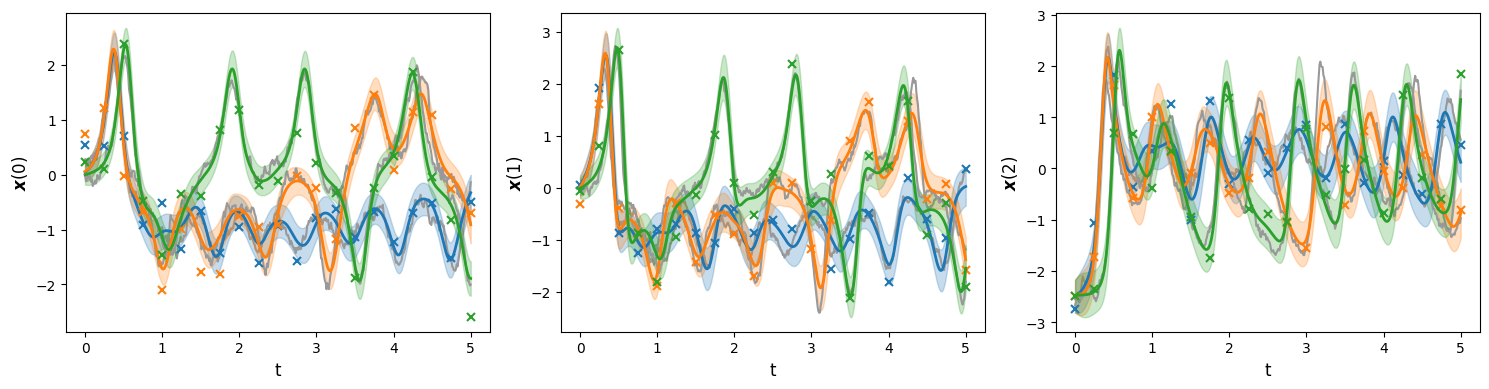

In [17]:
num_std = 2. 
fig, axs, _ = plot_posterior_marginals(ys_obs=ys_obs_partial[:n_trajs], obs_times=obs_times_partial[:n_trajs], post_net=post_net, encoder=encoder, params=params, process_ctx=process_ctx, P=params["output_params"]["C"], offset=params["output_params"]["d"], num_std=num_std, t_max=t_max, n_timesteps=n_timesteps, true_latents=ys_train[:n_trajs])
plt.show()

We can also draw samples from the approximate posterior SDE. 

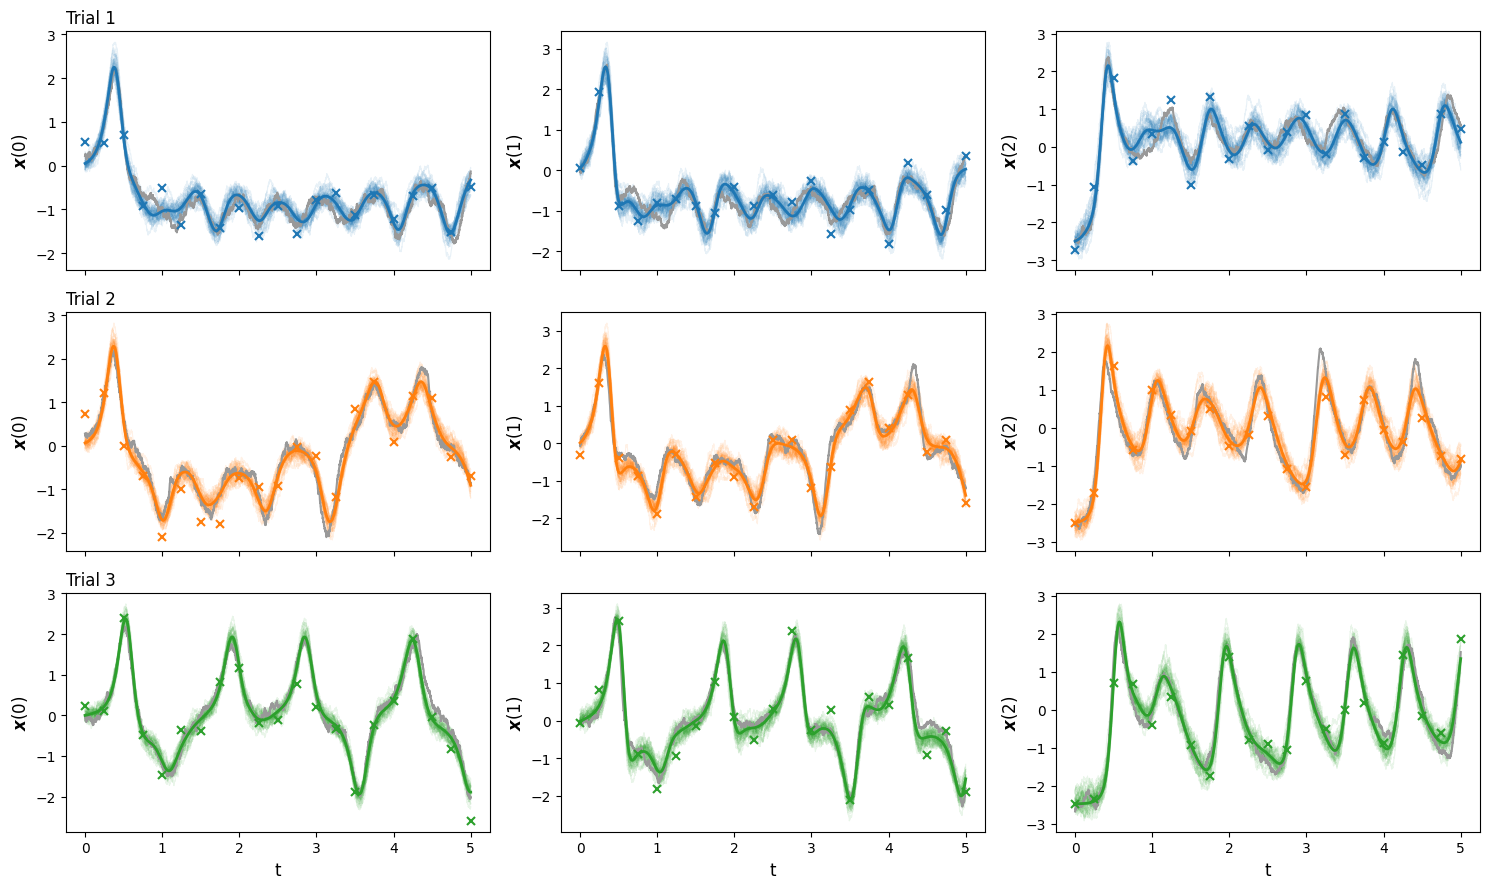

In [18]:
n_post_samples = 32
ctx_seqs = vmap(partial(encoder.apply, params["encoder_params"]))(ys_obs_partial[:n_trajs]) # (n_trajs, T, H) encodings of the observations

def sample_trial(key, ctx_seq, obs_times):
    posterior_sde = PosteriorSDE(prior, post_net, ctx_seq, partial(process_ctx, obs_times), gauge=gauge, div_free=div_free_eval)
    return simulate_posterior_samples(key, posterior_sde, params, t_max=t_max, n_timesteps=n_timesteps, n_samples=n_post_samples)
xs_post = vmap(sample_trial)(jr.split(jr.PRNGKey(7), n_trajs), ctx_seqs, obs_times_partial[:n_trajs]) # (n_trajs, n_post_samples, n_timesteps + 1, K)

fig, axs = plot_posterior_samples(xs_post, ys_obs=ys_obs_partial[:n_trajs], obs_times=obs_times_partial[:n_trajs], post_net=post_net, encoder=encoder, params=params, process_ctx=process_ctx, P=params["output_params"]["C"], offset=params["output_params"]["d"], true_latents=ys_train[:n_trajs], t_max=t_max, alpha=0.1)
plt.show()

We compare the posterior obtained from Helmholtz-SDE to that obtained from the iterated, extended Rauch-Tung-Striebel (RTS) smoother (Sarkka and Svensson, Chapter 13). 
We run the RTS smoother with prior dyamics equal to the Lorenz dynamics and likelihood model fixed to the ground truth.
The result is a proxy for the true (intractable) posterior; it is not a baseline algorithm.

In [19]:
# Run the iterated extended RTS smoother on the true Lorenz dynamics
n_smooth = n_trajs
res_ie_rts = run_ie_rts_smoother_batch_fast(
    ys_obs_batch=ys_obs_partial[:n_smooth],
    obs_idx=idx_obs,
    t_grid=t_grid,
    a=a,
    C_true=C_true,
    d_true=d_true,
    sigma=sigma,
    ssigma=ssigma,
    n_iters=50,
)

ms_ie_rts = res_ie_rts["m"] # (B, T, D), smoothed posterior means
Ss_ie_rts = res_ie_rts["S"] # (B, T, D, D), smoothed posterior covariances

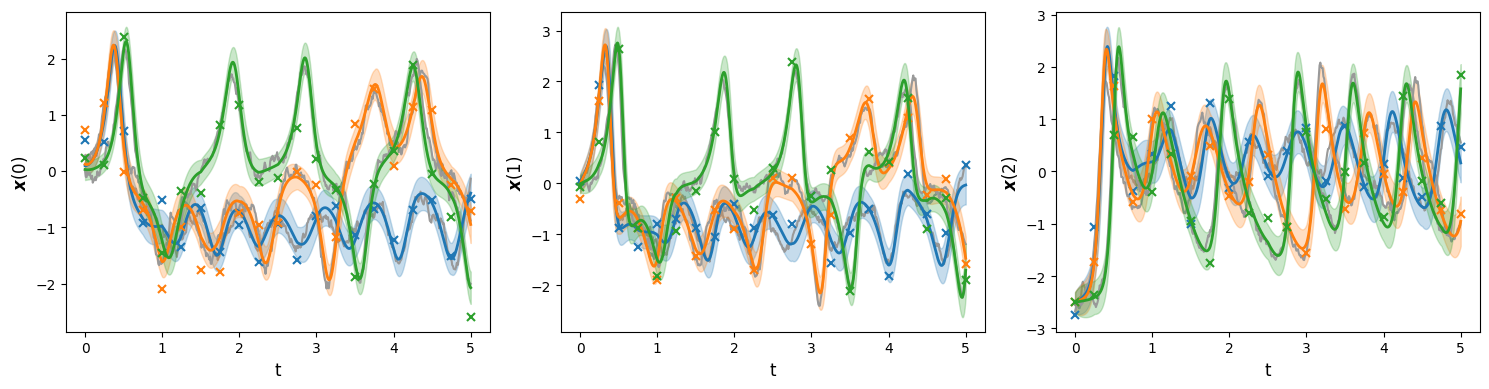

In [20]:
num_std = 2.
fig, axs = plot_rts_posterior_marginals(ys_obs=ys_obs_partial[:n_trajs], obs_times=obs_times_partial[:n_trajs], ms_rts=ms_ie_rts[:n_trajs], Ss_rts=Ss_ie_rts[:n_trajs], true_latents=ys_train[:n_trajs], t_max=t_max, num_std=num_std)
plt.show()

We observe that the posterior mean closely tracks the true latent trajectories, and the posterior uncertainty is well-calibrated. 
Moreover, these quantities agree with those obtained from the iterated extended RTS smoother.

We can also compute the log probability of the true trajectory under the posterior.

In [21]:
# Held-out log probability of the true latents under the posterior (evaluation times that are observation times are excluded)
eval_skip = 100 # subsample the time grid for tractability
n_eval = 256
logprob = posterior_true_logprob(ys_obs=ys_obs_partial[:n_eval], obs_times=obs_times_partial[:n_eval], ys_true=ys_train[:n_eval, ::eval_skip], t_grid=t_grid[::eval_skip], encoder=encoder, post_net=post_net, params=params, process_ctx=process_ctx, ssigma=ssigma)
print(f"Mean held-out log-prob of true latents under posterior: {logprob:.4f}")

Mean held-out log-prob of true latents under posterior: -0.0869


### Prior dynamics

We next assess the quality of the learned dynamics. 
We start by drawing and visualizing samples from the learned prior.

In [22]:
# Draw samples from the learned prior and map them from latent to observation space
eval_key = jr.PRNGKey(5)
n_eval = n_test
xs_eval = simulate_learned_prior_samples(eval_key, prior, params, t_max=t_max, n_timesteps=n_timesteps, n_eval=n_eval)
ys_eval = vmap(vmap(lambda x: params["output_params"]["C"] @ x + params["output_params"]["d"]))(xs_eval)

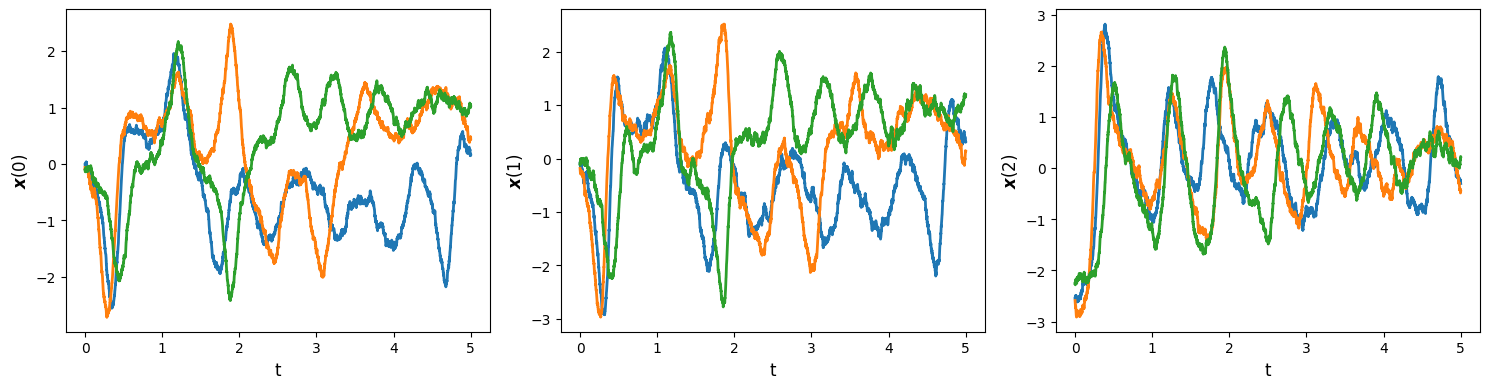

In [23]:
fig, axs = plot_marginal_trajectories(ys_eval, t_max=t_max, n_trajs=n_trajs, linewidth=2)
plt.show()

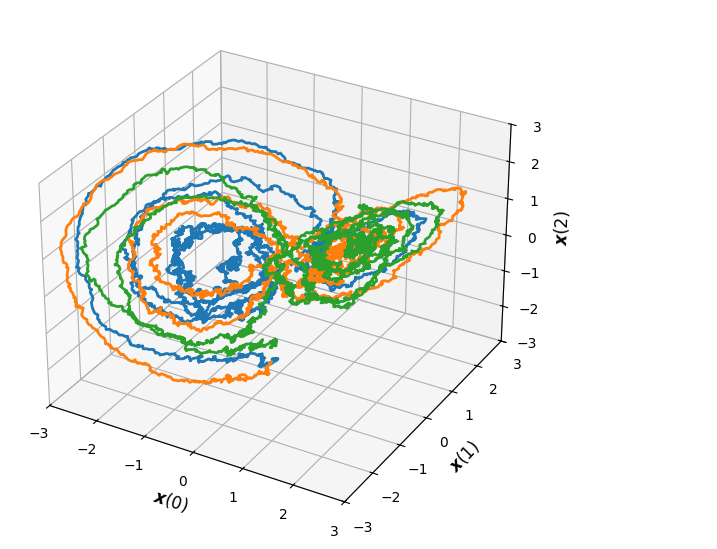

In [24]:
fig, ax = plot_latent_3d_projection(ys_eval, n_trajs=n_trajs, xlim=(-3, 3), ylim=(-3, 3), zlim=(-3, 3))

Visually, the simulated latent trajectories resemble the ground truth latents generated according to the Lorenz attractor dynamics. 
We investigate this further by computing and plotting the lagged autocorrelation, both globally and within each lobe of the Lorenz attractor.

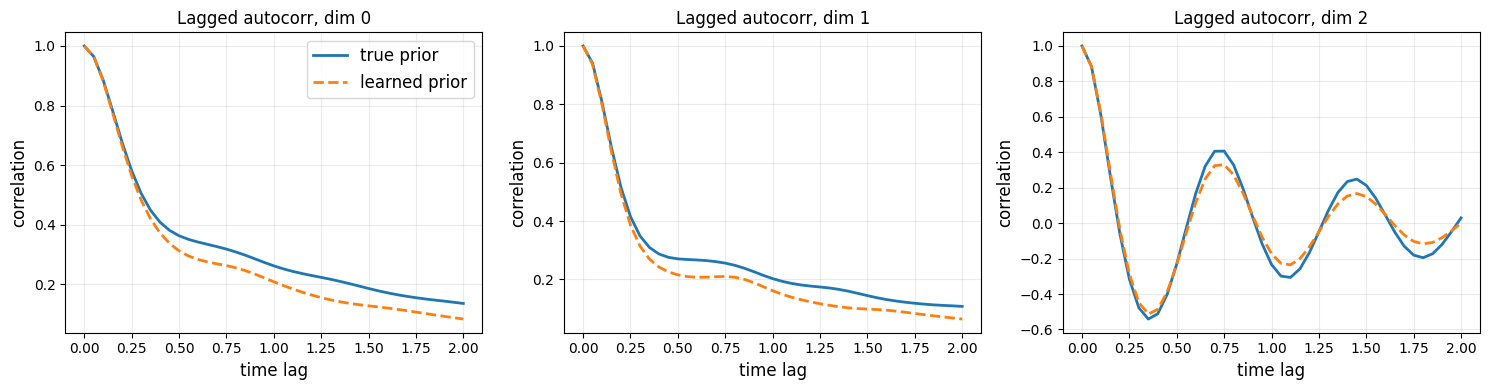

In [25]:
fig, axs = plot_lagged_autocorr_compare(ys_test, ys_eval, max_lag=2000, skip=50, start_idx=1000, dt=t_grid[1]- t_grid[0])

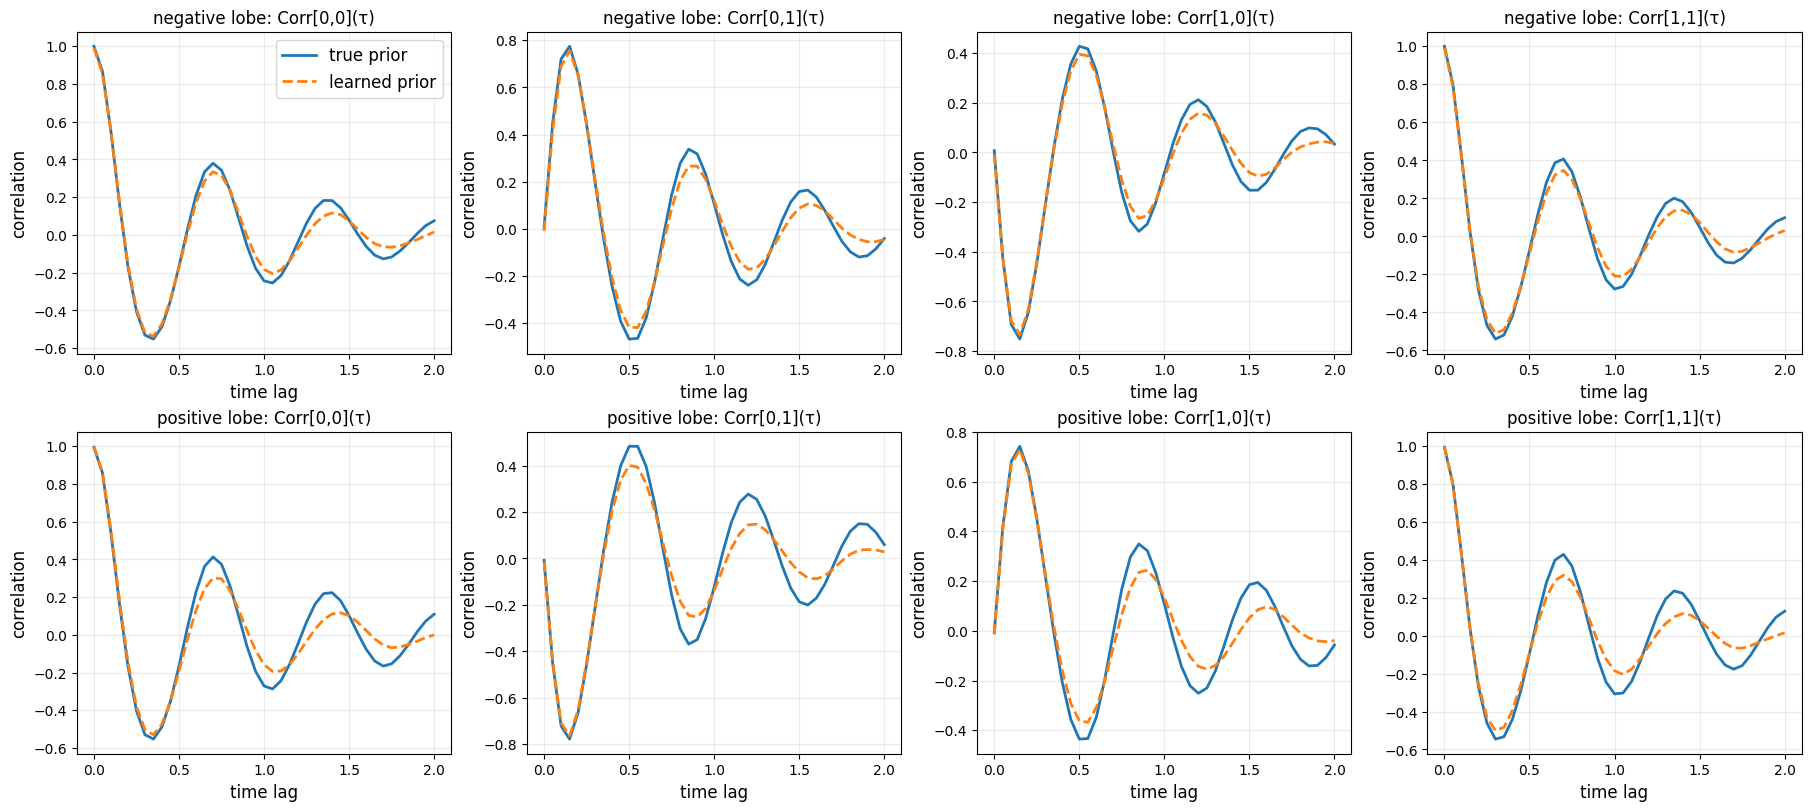

In [26]:
centers = compute_lorenz_fixed_points(means, stds) # centers of the two lobes of the Lorenz attractor

results = compute_lorenz_rotation_summaries(ys_test, ys_eval, centers=centers, min_count=50, max_lag=2000, skip=50, fit_radius_quantile=0.95)

fig, axs = plot_lobe_lagged_correlation_matrices(results, dt=t_grid[1]- t_grid[0])
plt.show()

Within each lobe of the attractor, Helmholtz-SDE learns oscillations that resemble those of the Lorenz attractor. 
This is visible in the time-lagged autocorrelations, which oscillate as a function of time.